In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt

In [2]:
df = pd.read_csv("supplytrend1.csv")
df.head()

,Months,Estimated Installed Capacity
0,2020-01,504.343735
1,2020-02,394.830195
2,2020-03,407.247325
3,2020-04,496.949363
4,2020-05,650.543751


In [3]:
df.columns = ["Months", "Capacity"]
df["Months"] = pd.to_datetime(df["Months"])
df.index = df["Months"]

In [4]:
df.head()

,Months,Capacity
Months,,
2020-01-01,2020-01-01,504.343735
2020-02-01,2020-02-01,394.830195
2020-03-01,2020-03-01,407.247325
2020-04-01,2020-04-01,496.949363
2020-05-01,2020-05-01,650.543751


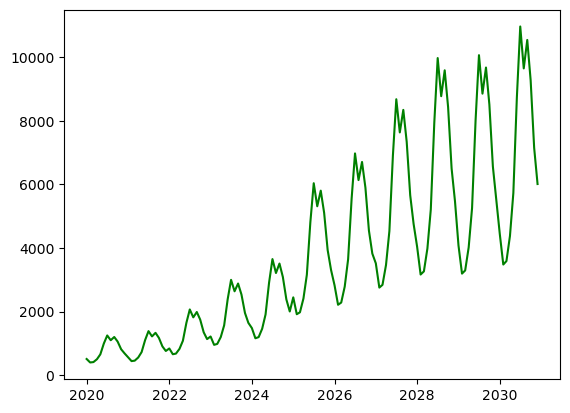

In [5]:
plt.plot(df["Months"], df["Capacity"], color="green")
plt.show()

In [6]:
max_train = df.tail(20).iloc[0]["Months"]
max_train

Timestamp('2029-05-01 00:00:00')

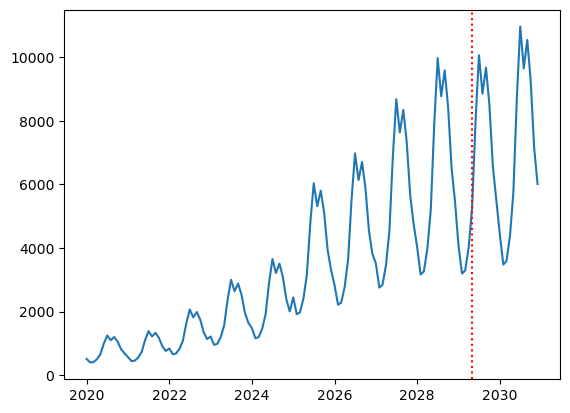

In [7]:
plt.plot(df['Months'], df['Capacity'])
plt.axvline(max_train, color='red', linestyle='dotted')
plt.show()

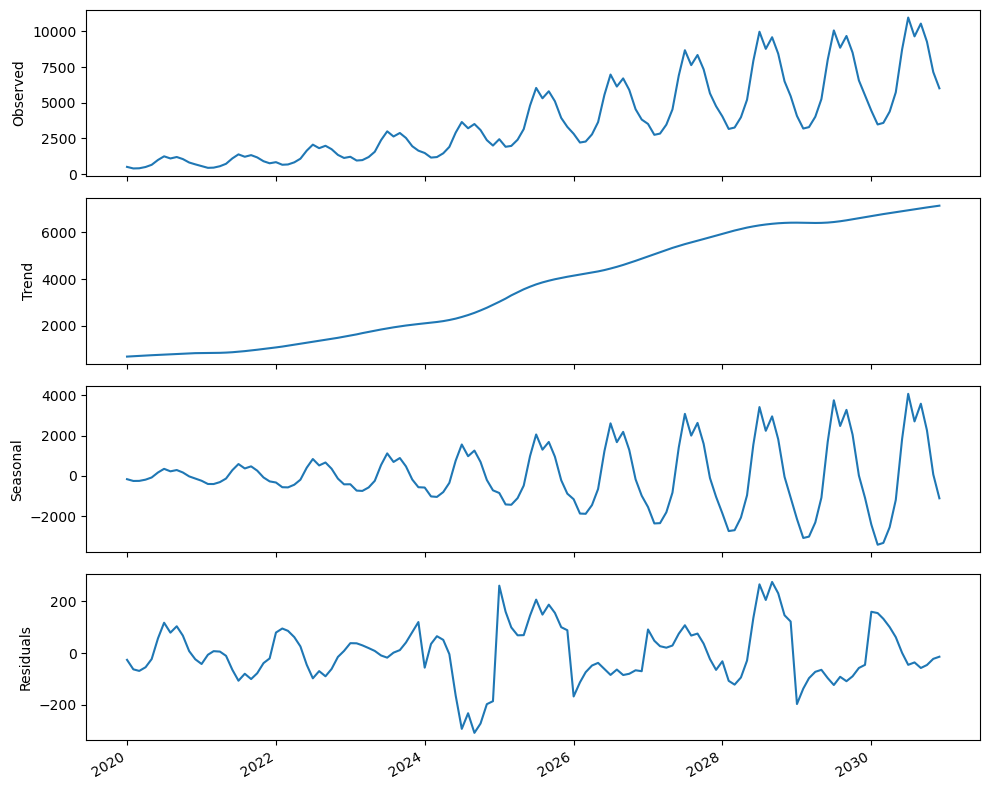

In [8]:
from statsmodels.tsa.seasonal import seasonal_decompose, STL

decomposition = STL(df['Capacity'], period=12).fit()

fig, (ax1, ax2, ax3, ax4) = plt.subplots(nrows=4, ncols=1, sharex=True, figsize=(10,8))

ax1.plot(decomposition.observed)
ax1.set_ylabel('Observed')

ax2.plot(decomposition.trend)
ax2.set_ylabel('Trend')

ax3.plot(decomposition.seasonal)
ax3.set_ylabel('Seasonal')

ax4.plot(decomposition.resid)
ax4.set_ylabel('Residuals')

fig.autofmt_xdate()
plt.tight_layout()

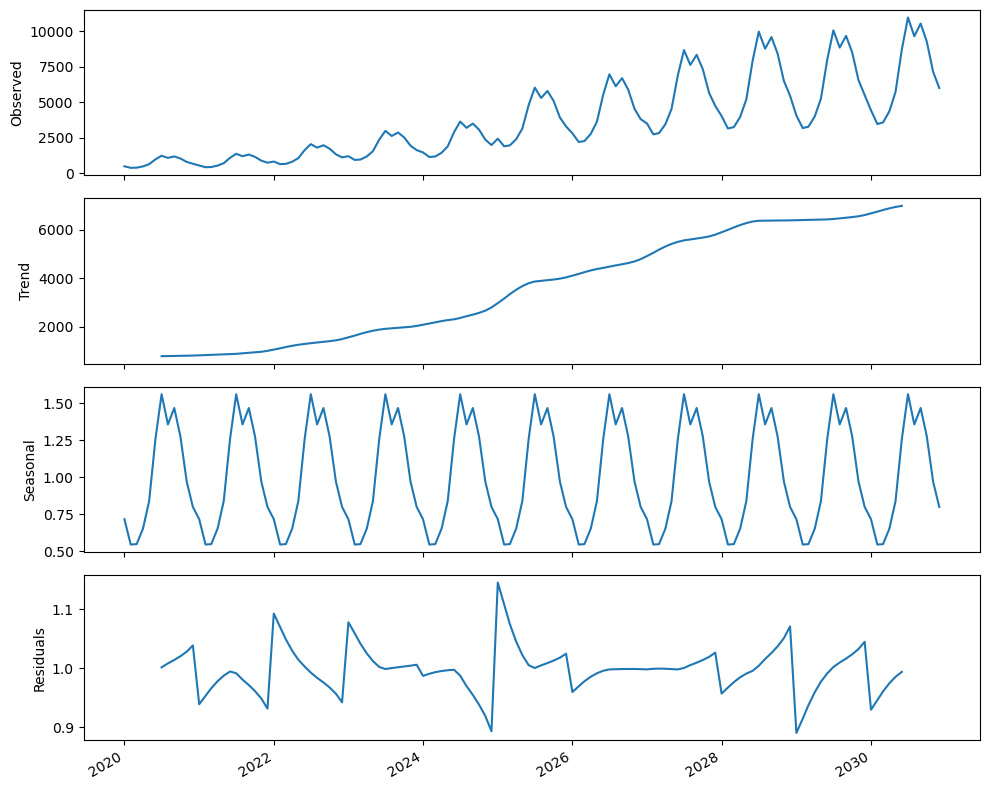

In [9]:
decomposition = seasonal_decompose(df['Capacity'],
                                         model = 'multiplicative',
                                         period=12 #52 to 53 weeks in a year
                                         )

fig, (ax1, ax2, ax3, ax4) = plt.subplots(nrows=4, ncols=1, sharex=True, figsize=(10,8))

ax1.plot(decomposition.observed)
ax1.set_ylabel('Observed')

ax2.plot(decomposition.trend)
ax2.set_ylabel('Trend')

ax3.plot(decomposition.seasonal)
ax3.set_ylabel('Seasonal')

ax4.plot(decomposition.resid)
ax4.set_ylabel('Residuals')

fig.autofmt_xdate()
plt.tight_layout()

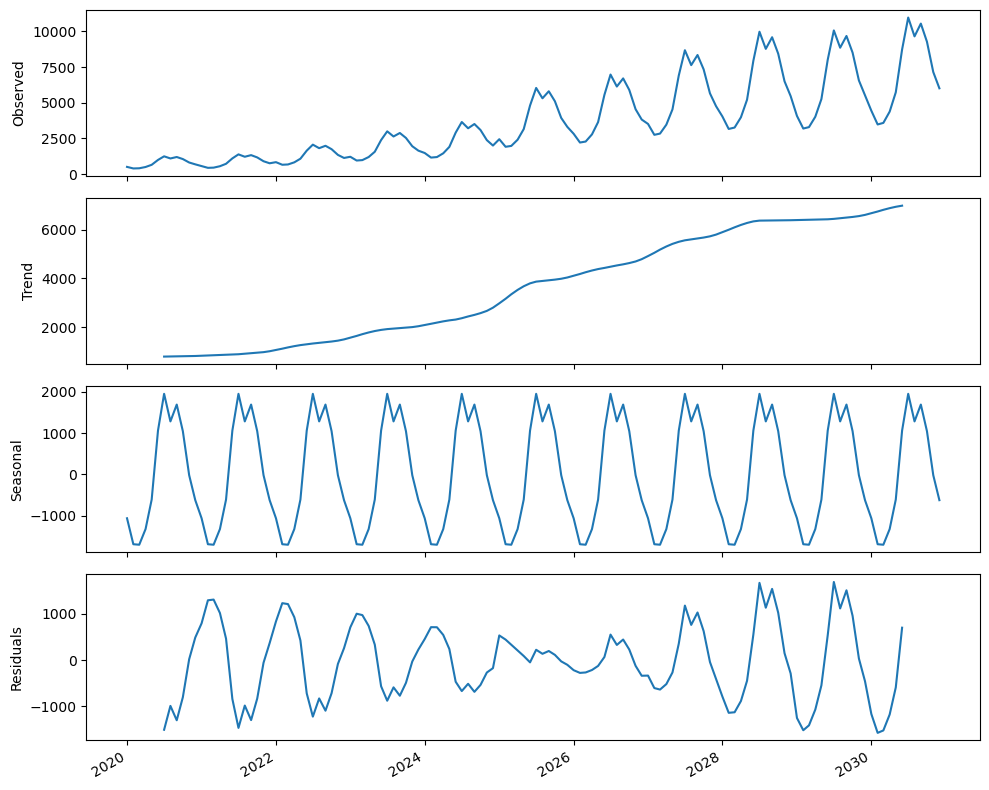

In [10]:
decomposition = seasonal_decompose(df['Capacity'],
                                         model = 'additive',
                                         period=12 #52 to 53 weeks in a year
                                         )

fig, (ax1, ax2, ax3, ax4) = plt.subplots(nrows=4, ncols=1, sharex=True, figsize=(10,8))

ax1.plot(decomposition.observed)
ax1.set_ylabel('Observed')

ax2.plot(decomposition.trend)
ax2.set_ylabel('Trend')

ax3.plot(decomposition.seasonal)
ax3.set_ylabel('Seasonal')

ax4.plot(decomposition.resid)
ax4.set_ylabel('Residuals')

fig.autofmt_xdate()
plt.tight_layout()

In [11]:
from statsmodels.tsa.stattools import kpss, adfuller

def obtain_adf_kpss_results(timeseries, max_d):
    """ Build dataframe with ADF statistics and p-value for time series after applying difference on time series
    
    Args:
        time_series (df): Dataframe of univariate time series  
        max_d (int): Max value of how many times apply difference
        
    Returns:
        Dataframe showing values of ADF statistics and p when applying ADF test after applying d times 
        differencing on a time-series.
    
    """
    
    results=[]

    for idx in range(max_d):
        adf_result = adfuller(timeseries, autolag='AIC')
        kpss_result = kpss(timeseries, regression='c', nlags="auto")
        timeseries = timeseries.diff().dropna()
        if adf_result[1] <=0.05:
            adf_stationary = True
        else:
            adf_stationary = False
        if kpss_result[1] <=0.05:
            kpss_stationary = False
        else:
            kpss_stationary = True
            
        stationary = adf_stationary & kpss_stationary
            
        results.append((idx,adf_result[1], kpss_result[1],adf_stationary,kpss_stationary, stationary))
    
    # Construct DataFrame 
    results_df = pd.DataFrame(results, columns=['d','adf_stats','p-value', 'is_adf_stationary','is_kpss_stationary','is_stationary' ])
    
    return results_df

In [12]:
obtain_adf_kpss_results(df["Capacity"], 2)

C:\Users\ashal\AppData\Local\Temp\ipykernel_3640\3815540397.py:20: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_result = kpss(timeseries, regression='c', nlags="auto")
C:\Users\ashal\AppData\Local\Temp\ipykernel_3640\3815540397.py:20: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(timeseries, regression='c', nlags="auto")


,d,adf_stats,p-value,is_adf_stationary,is_kpss_stationary,is_stationary
0,0,0.910768,0.01,False,False,False
1,1,0.024997,0.10,True,True,True


In [13]:
df_train = df.loc[df["Months"] < max_train , :]
df_test = df.loc[df["Months"] >= max_train, :]

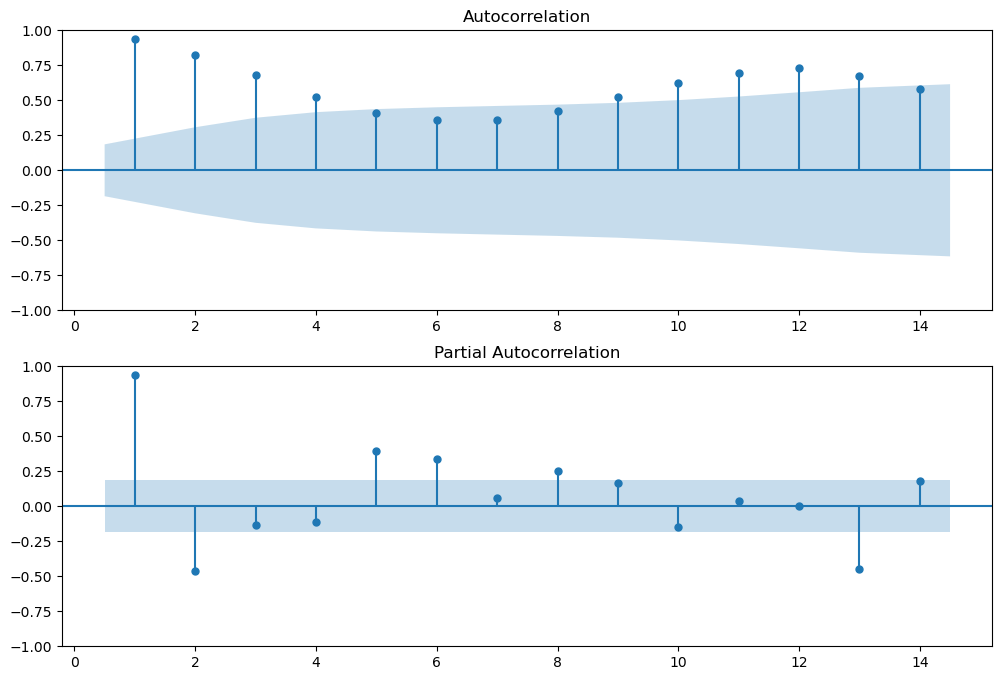

In [14]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, (ax1, ax2) = plt.subplots(2,1, figsize=(12,8))
 
plot_acf(df_train["Capacity"], lags=14, zero=False, ax=ax1)
plot_pacf(df_train["Capacity"], lags=14, zero=False, ax=ax2)

plt.show()

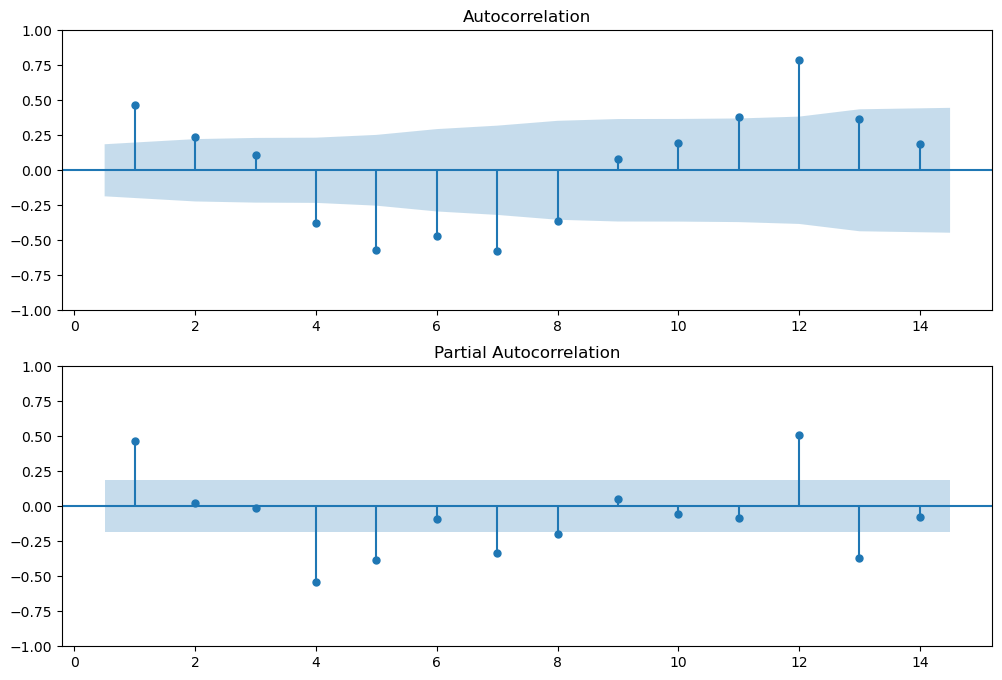

In [15]:
fig, (ax1, ax2) = plt.subplots(2,1, figsize=(12,8))
 
plot_acf(df_train["Capacity"].diff().dropna(), lags=14, zero=False, ax=ax1)
plot_pacf(df_train["Capacity"].diff().dropna(), lags=14, zero=False, ax=ax2)

plt.show()

In [16]:
from itertools import product
from typing import Union
from tqdm.notebook import tqdm
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.tsa.statespace.sarimax import SARIMAX

def optimize_SARIMA(endog: Union[pd.Series, list], order_list: list, d: int, D: int, s: int) -> pd.DataFrame:
    
    results = []
    
    for order in tqdm(order_list):
        try: 
            model = SARIMAX(
                endog, 
                order=(order[0], d, order[1]),
                seasonal_order=(order[2], D, order[3], s),
                simple_differencing=False).fit(disp=False)
        except Exception as e:
            print(f"Error for order {order}: {e}")  # Print the error for debugging:
            continue
            
        bic = model.bic
        results.append([order, bic])
        
    # result_df = pd.DataFrame(results)
    # result_df.columns = ['(p,q,P,Q)', 'AIC']
    
    # #Sort in ascending order, lower AIC is better
    # result_df = result_df.sort_values(by='AIC', ascending=True).reset_index(drop=True)
    if results:
        result_df = pd.DataFrame(results, columns=['(p,q,P,Q)', 'BIC'])
        # Sort in ascending order, lower AIC is better
        result_df = result_df.sort_values(by='BIC', ascending=True).reset_index(drop=True)
    else:
        # Return an empty DataFrame with the expected columns if no models were fitted
        result_df = pd.DataFrame(columns=['(p,q,P,Q)', 'BIC'])
    
    return result_df

In [17]:
df_train["Capacity"]

Months
2020-01-01     504.343735
2020-02-01     394.830195
2020-03-01     407.247325
2020-04-01     496.949363
2020-05-01     650.543751
                 ...     
2028-12-01    5469.321362
2029-01-01    4078.505729
2029-02-01    3192.896236
2029-03-01    3293.310561
2029-04-01    4018.709232
Name: Capacity, Length: 112, dtype: float64

In [18]:
ps = np.arange(0, 4, 1)
qs = np.arange(0, 4, 1)
Ps = np.arange(0, 4, 1)
Qs = np.arange(0, 4, 1)

SARIMA_order_list = list(product(ps, qs, Ps, Qs))

train = df_train['Capacity']

d = 0
D = 1
s = 12

SARIMA_result_df = optimize_SARIMA(train, SARIMA_order_list, d, D, s)
SARIMA_result_df

  0%|          | 0/256 [00:00<?, ?it/s]

C:\Users\ashal\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\ashal\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\ashal\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\ashal\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\ashal\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  

Error for order (0, 1, 2, 1): LU decomposition error.


C:\Users\ashal\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\ashal\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\ashal\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\ashal\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\ashal\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency 

Error for order (3, 2, 3, 2): LU decomposition error.


C:\Users\ashal\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\ashal\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\ashal\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'
C:\Users\ashal\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\Users\ashal\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_m

,"(p,q,P,Q)",BIC
0,"(0, 1, 3, 2)",3.223619e+01
1,"(1, 3, 2, 3)",4.605170e+01
2,"(1, 3, 3, 3)",5.065687e+01
3,"(2, 3, 2, 3)",5.065687e+01
4,"(0, 1, 2, 3)",1.865085e+02
...,...,...
249,"(0, 0, 0, 2)",1.564792e+03
250,"(0, 0, 1, 0)",1.570793e+03
251,"(0, 0, 0, 1)",1.609838e+03
252,"(0, 0, 0, 0)",1.637453e+03


In [19]:
train = df_train['Capacity']

SARIMA_model = SARIMAX(train, order=(0,0,1), trend=(1,0), seasonal_order=(3,1,2,12), simple_differencing=False)
SARIMA_model_fit = SARIMA_model.fit(disp=False)

print(SARIMA_model_fit.summary())

C:\Users\ashal\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\ashal\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\ashal\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:997: UserWarning: Non-stationary starting seasonal autoregressive Using zeros as starting parameters.
  warn('Non-stationary starting seasonal autoregressive'


                                        SARIMAX Results                                        
Dep. Variable:                                Capacity   No. Observations:                  112
Model:             SARIMAX(0, 0, 1)x(3, 1, [1, 2], 12)   Log Likelihood                -687.902
Date:                                 Sat, 13 Sep 2025   AIC                           1391.804
Time:                                         22:15:14   BIC                           1412.645
Sample:                                     01-01-2020   HQIC                          1400.239
                                          - 04-01-2029                                         
Covariance Type:                                   opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept    664.1326    468.376      1.418      0.156    -253.868    1582

C:\Users\ashal\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


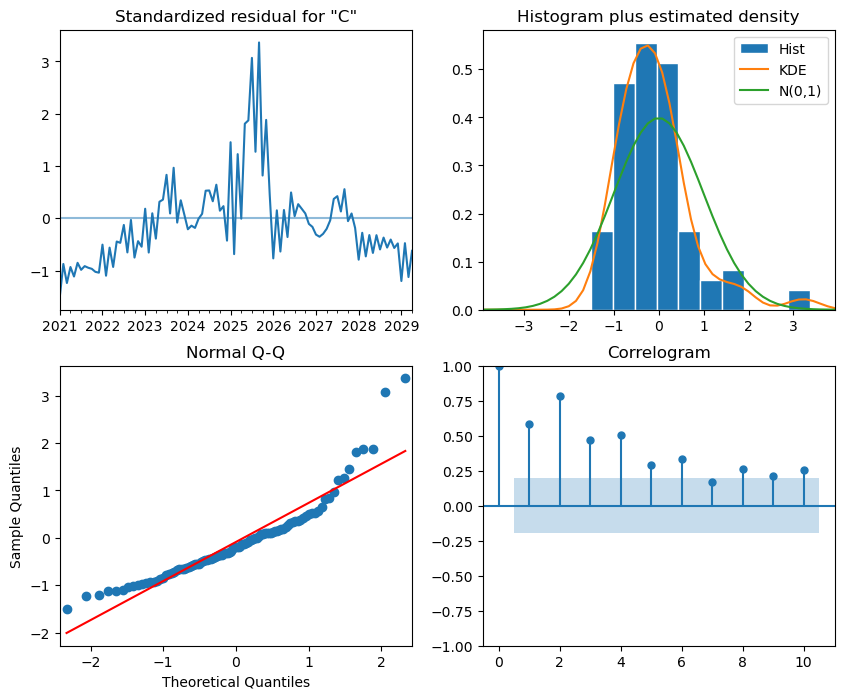

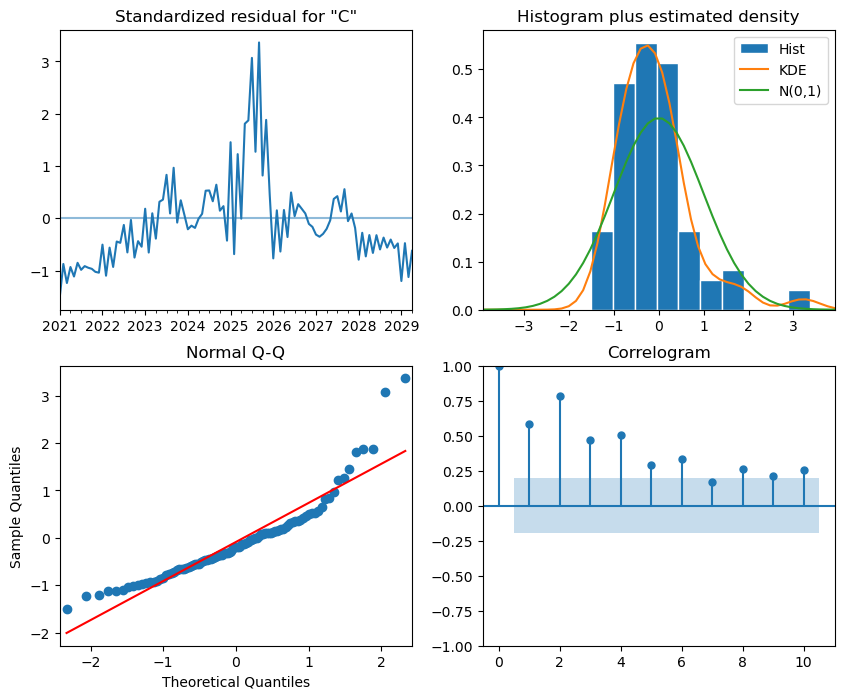

In [20]:
SARIMA_model_fit.plot_diagnostics(figsize=(10,8))

In [21]:
residuals = SARIMA_model_fit.resid

lbvalue, pvalue = acorr_ljungbox(residuals, np.arange(1, 11, 1))
print(pvalue)

lb_pvalue


C:\Users\ashal\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\ashal\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\ashal\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:997: UserWarning: Non-stationary starting seasonal autoregressive Using zeros as starting parameters.
  warn('Non-stationary starting seasonal autoregressive'
C:\Users\ashal\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


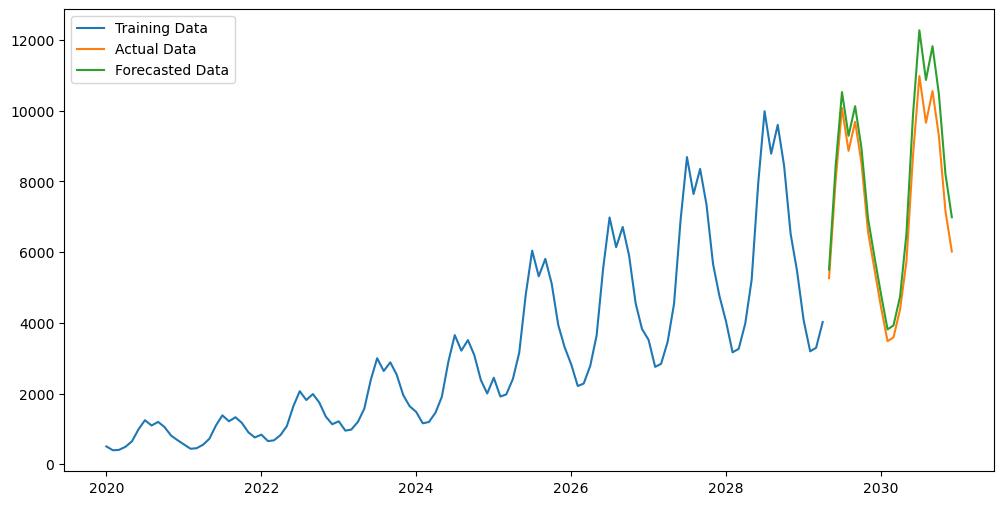

In [22]:
model = SARIMAX(
    endog = df_train['Capacity'], 
    order = (0, 0, 1), # p, d, q order parameters for arima
    trend = [1, 0], # A(t) = a0 + a1*t + a2*t^2 ... 
    seasonal_order = (3,1,2, 12) # P, D, Q seasonal order parameters
).fit()

forecast = model.forecast(steps=df_test.shape[0])

plt.figure(figsize = (12, 6))
plt.plot(df_train['Months'], df_train['Capacity'], label='Training Data')
plt.plot(df_test['Months'], df_test['Capacity'], label='Actual Data')
plt.plot(df_test['Months'], forecast, label='Forecasted Data')
plt.legend()
plt.show()

C:\Users\ashal\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\ashal\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\ashal\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:997: UserWarning: Non-stationary starting seasonal autoregressive Using zeros as starting parameters.
  warn('Non-stationary starting seasonal autoregressive'
C:\Users\ashal\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


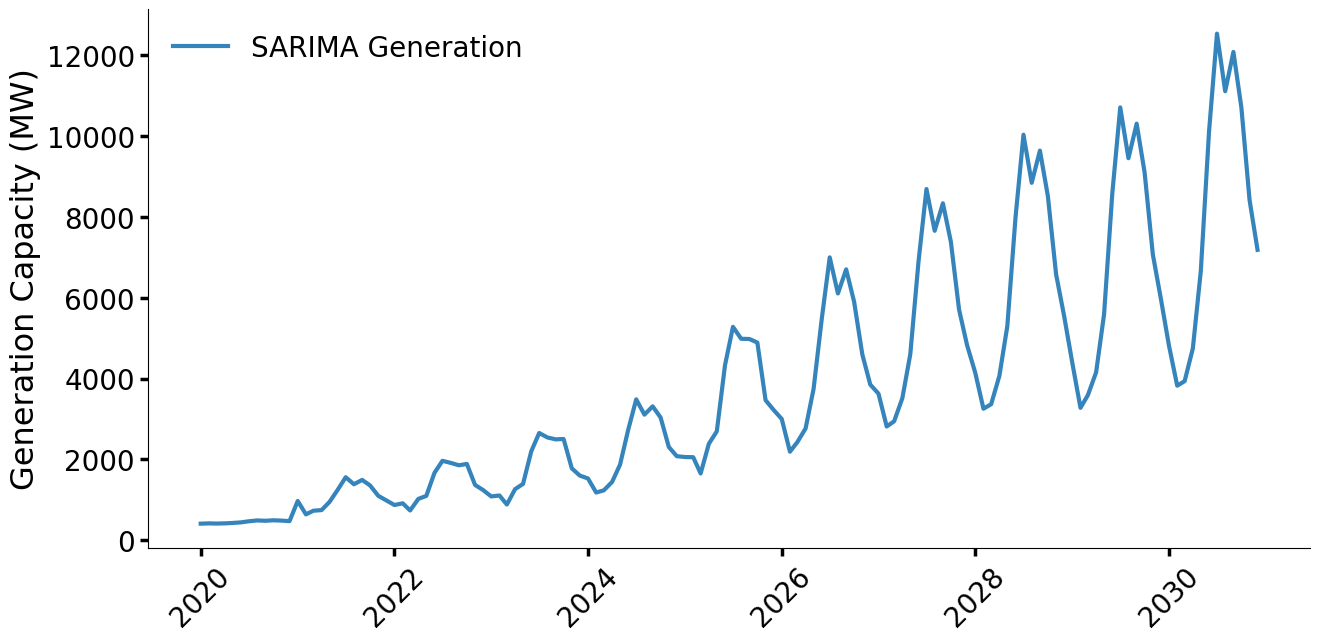

In [27]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import matplotlib.pyplot as plt

# Split the data
df_train = df.loc[df["Months"] < max_train , :]
df_test = df.loc[df["Months"] >= max_train, :]

# Fit the model
model = SARIMAX(
    endog = df_train['Capacity'], 
    order = (0, 0, 1),
    trend = 'ct',  # trend='ct' gives both constant and linear trend
    seasonal_order = (3,1,2,12)
).fit()

# Get predictions for the entire span (training + testing)
n_total_steps = df_train.shape[0] + df_test.shape[0]
pred = model.get_prediction(start=0, end=n_total_steps - 1)
forecast_all = pred.predicted_mean

# Concatenate months from training and test data for plotting
months_all = pd.concat([df_train['Months'], df_test['Months']])

# Plotting
# plt.figure(figsize=(12, 6))
fig, ax = plt.subplots(figsize=(15, 7))
# plt.plot(df['Months'], df['Capacity'], label='Bhandari and Subedi Generation', lw=1.8, c="r", alpha=0.9, linestyle=":")
# plt.plot(df_test['Months'], df_test['Capacity'], label='Actual Data')
ax.plot(months_all, forecast_all, label='SARIMA Generation', lw=3, alpha=0.9)
# ax.set_xlabel("Years", fontsize="14")
ax.set_ylabel("Generation Capacity (MW)", fontsize=23)
plt.xticks(rotation = 45, fontsize=20)
plt.yticks(fontsize=20)
plt.tick_params(axis='both', which='major', length=6, width=2.5)  
ax.legend(fontsize=20, frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.savefig("sarima.png", dpi=300)
plt.show()


In [ ]:
from math import sqrt
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score

mse = mean_squared_error(df_test['Capacity'], forecast)
print('MSE: '+str(mse))
mae = mean_absolute_error(df_test['Capacity'], forecast)
print('MAE: '+str(mae))
rmse = sqrt(mean_squared_error(df_test['Capacity'], forecast))
print('RMSE: '+str(rmse))
mape = mean_absolute_percentage_error(df_test['Capacity'], forecast) * 100  # Convert to percentage
r2 = r2_score(df_test['Capacity'], forecast)

print(f'MAPE: {mape:.2f}%')
print(f'R²: {r2:.4f}')

In [18]:
from math import sqrt
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score

mse = mean_squared_error(df['Capacity'], forecast_all)
print('MSE: '+str(mse))
mae = mean_absolute_error(df['Capacity'], forecast_all)
print('MAE: '+str(mae))
rmse = sqrt(mean_squared_error(df['Capacity'], forecast_all))
print('RMSE: '+str(rmse))
mape = mean_absolute_percentage_error(df['Capacity'], forecast_all) * 100  # Convert to percentage
r2 = r2_score(df['Capacity'], forecast_all)

print(f'MAPE: {mape:.2f}%')
print(f'R²: {r2:.4f}')

MSE: 182469.53507348138
MAE: 264.2895538557005
RMSE: 427.1645292782178
MAPE: 11.18%
R²: 0.9767


In [24]:
forecast2040 = model.forecast(140)
forecast2040

2029-05-01     5503.071210
2029-06-01     8425.829533
2029-07-01    10521.402356
2029-08-01     9286.087861
2029-09-01    10124.526116
                  ...     
2040-08-01    19133.394798
2040-09-01    20245.291331
2040-10-01    18666.975231
2040-11-01    16029.366481
2040-12-01    14598.118316
Freq: MS, Name: predicted_mean, Length: 140, dtype: float64

In [25]:
from pandas.tseries.offsets import DateOffset

future_dates=[df.index[-1]+ DateOffset(months=x)for x in range(-20,121)]
future_datest_df=pd.DataFrame(index=future_dates[1:],columns=df.columns)

In [26]:
future_datest_df.head()

,Months,Capacity
2029-05-01,NaN,NaN
2029-06-01,NaN,NaN
2029-07-01,NaN,NaN
2029-08-01,NaN,NaN
2029-09-01,NaN,NaN


In [27]:
future_datest_df.tail()

,Months,Capacity
2040-08-01,NaN,NaN
2040-09-01,NaN,NaN
2040-10-01,NaN,NaN
2040-11-01,NaN,NaN
2040-12-01,NaN,NaN


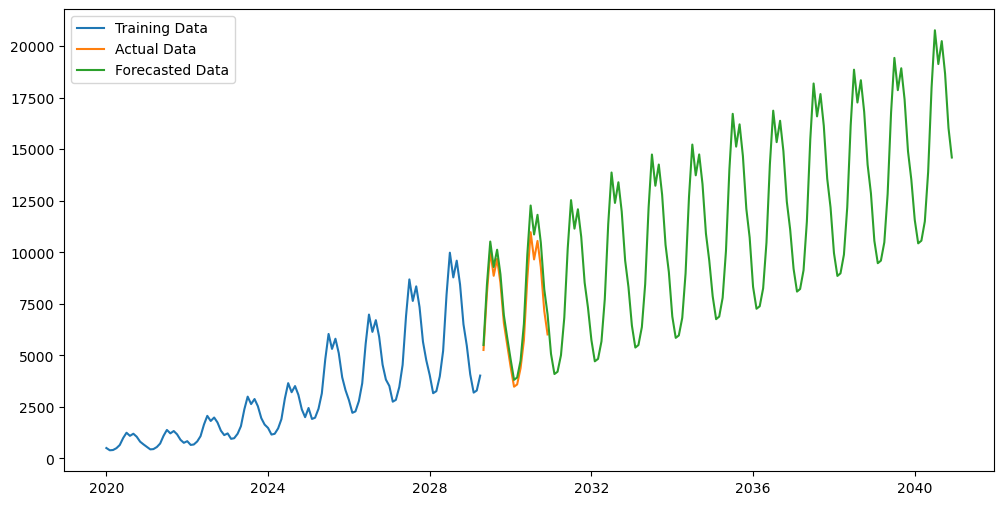

In [28]:
plt.figure(figsize = (12, 6))
plt.plot(df_train['Months'], df_train['Capacity'], label='Training Data')
plt.plot(df_test['Months'], df_test['Capacity'], label='Actual Data')
plt.plot(future_datest_df.index, forecast2040, label='Forecasted Data')
plt.legend()
plt.show()

In [29]:
pd.set_option('display.max_rows', None)  # Ensure all rows are shown
print(forecast2040)

2029-05-01     5503.071210
2029-06-01     8425.829533
2029-07-01    10521.402356
2029-08-01     9286.087861
2029-09-01    10124.526116
2029-10-01     8934.436311
2029-11-01     6945.548508
2029-12-01     5868.160303
2030-01-01     4810.652682
2030-02-01     3811.883029
2030-03-01     3925.195140
2030-04-01     4744.045871
2030-05-01     6519.827458
2030-06-01     9887.718781
2030-07-01    12269.644834
2030-08-01    10865.445692
2030-09-01    11818.523176
2030-10-01    10465.857487
2030-11-01     8205.108408
2030-12-01     6985.141921
2031-01-01     5072.447046
2031-02-01     4094.250367
2031-03-01     4205.211500
2031-04-01     5007.002874
2031-05-01     6829.306614
2031-06-01    10184.542125
2031-07-01    12530.885324
2031-08-01    11147.770022
2031-09-01    12086.520329
2031-10-01    10754.002334
2031-11-01     8527.137059
2031-12-01     7319.413188
2032-01-01     5745.904941
2032-02-01     4711.358568
2032-03-01     4828.744121
2032-04-01     5677.091558
2032-05-01     7731.236983
2

In [31]:
forecast2040.to_csv("forecast.csv")